In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import xgboost, catboost, lightgbm, optuna,shap
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv(r'../data/wnba_players_data.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()

,Season,Player,G,MP,GS,FG,FGA,FG%,3P,3PA,...,USG%,ORtg,DRtg,OWS,DWS,WS,WS/40,PLUS_MINUS,award_share,is_mvp
0,1997,Anita Maxwell,9,63,0,8,25,0.320,0,0,...,25.6,72.0,89.0,-0.2,0.1,-0.1,-0.036,-5,0.0,0
1,1997,Tammi Reiss,28,831,26,72,231,0.312,30,101,...,17.0,87.0,105.0,0.2,-0.7,-0.5,-0.024,-288,0.0,0
2,1997,Catarina Pollini,13,94,0,8,22,0.364,0,0,...,17.6,77.0,92.0,-0.1,0.1,0.0,0.005,19,0.0,0
3,1997,Bridget Pettis,28,842,28,107,320,0.334,41,134,...,24.0,94.0,88.0,1.5,1.7,3.2,0.151,91,0.0,0
4,1997,Kim Perrot,28,692,24,59,162,0.364,28,99,...,16.5,87.0,87.0,0.2,1.5,1.7,0.098,155,0.0,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4691 entries, 0 to 4690
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Season       4691 non-null   int64  
 1   Player       4691 non-null   str    
 2   G            4691 non-null   int64  
 3   MP           4691 non-null   int64  
 4   GS           4691 non-null   int64  
 5   FG           4691 non-null   int64  
 6   FGA          4691 non-null   int64  
 7   FG%          4691 non-null   float64
 8   3P           4691 non-null   int64  
 9   3PA          4691 non-null   int64  
 10  3P%          4691 non-null   float64
 11  2P           4691 non-null   int64  
 12  2PA          4691 non-null   int64  
 13  2P%          4691 non-null   float64
 14  FT           4691 non-null   int64  
 15  FTA          4691 non-null   int64  
 16  FT%          4691 non-null   float64
 17  ORB          4691 non-null   int64  
 18  TRB          4691 non-null   int64  
 19  AST          4691

In [4]:
data.isna().sum()

Season         0
Player         0
G              0
MP             0
GS             0
FG             0
FGA            0
FG%            0
3P             0
3PA            0
3P%            0
2P             0
2PA            0
2P%            0
FT             0
FTA            0
FT%            0
ORB            0
TRB            0
AST            0
STL            0
BLK            0
TOV            0
PF             0
PTS            0
PER            0
TS%            0
eFG%           0
3PAr           0
FTr            0
ORB%           0
TRB%           0
AST%           0
STL%           0
BLK%           0
TOV%           0
USG%           0
ORtg           0
DRtg           0
OWS            0
DWS            0
WS             0
WS/40          0
PLUS_MINUS     0
award_share    0
is_mvp         0
dtype: int64

In [5]:
data.columns

Index(['Season', 'Player', 'G', 'MP', 'GS', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PER', 'TS%', 'eFG%', '3PAr', 'FTr',
       'ORB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'ORtg', 'DRtg',
       'OWS', 'DWS', 'WS', 'WS/40', 'PLUS_MINUS', 'award_share', 'is_mvp'],
      dtype='str')

In [6]:
df = pd.DataFrame()
# features that show players skill level as well as their impact on the court
df = data[['Season', 'Player', 'TS%','WS', 'PER', 'USG%','PLUS_MINUS','award_share','is_mvp']]
df['pts_per_game'] = data['PTS'] / data['G']
df['stl_per_game'] = data['STL'] / data['G']
df['ast_per_game'] = data['AST'] / data['G']
df['trb_per_game'] = data['TRB'] / data['G']
df['blk_per_game'] = data['BLK'] / data['G']

In [7]:
sns.set_style('darkgrid')
sns.set_palette('colorblind')
sns.set(font_scale=0.8)

Explarotary Data Analysis

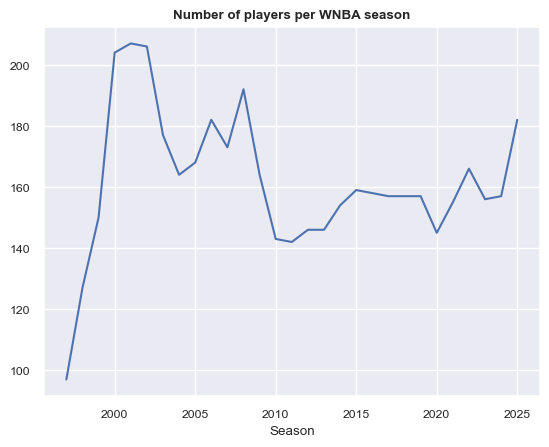

In [8]:
df['Season'].value_counts(sort=False).plot.line()
plt.title("Number of players per WNBA season", fontweight='bold')
plt.show()

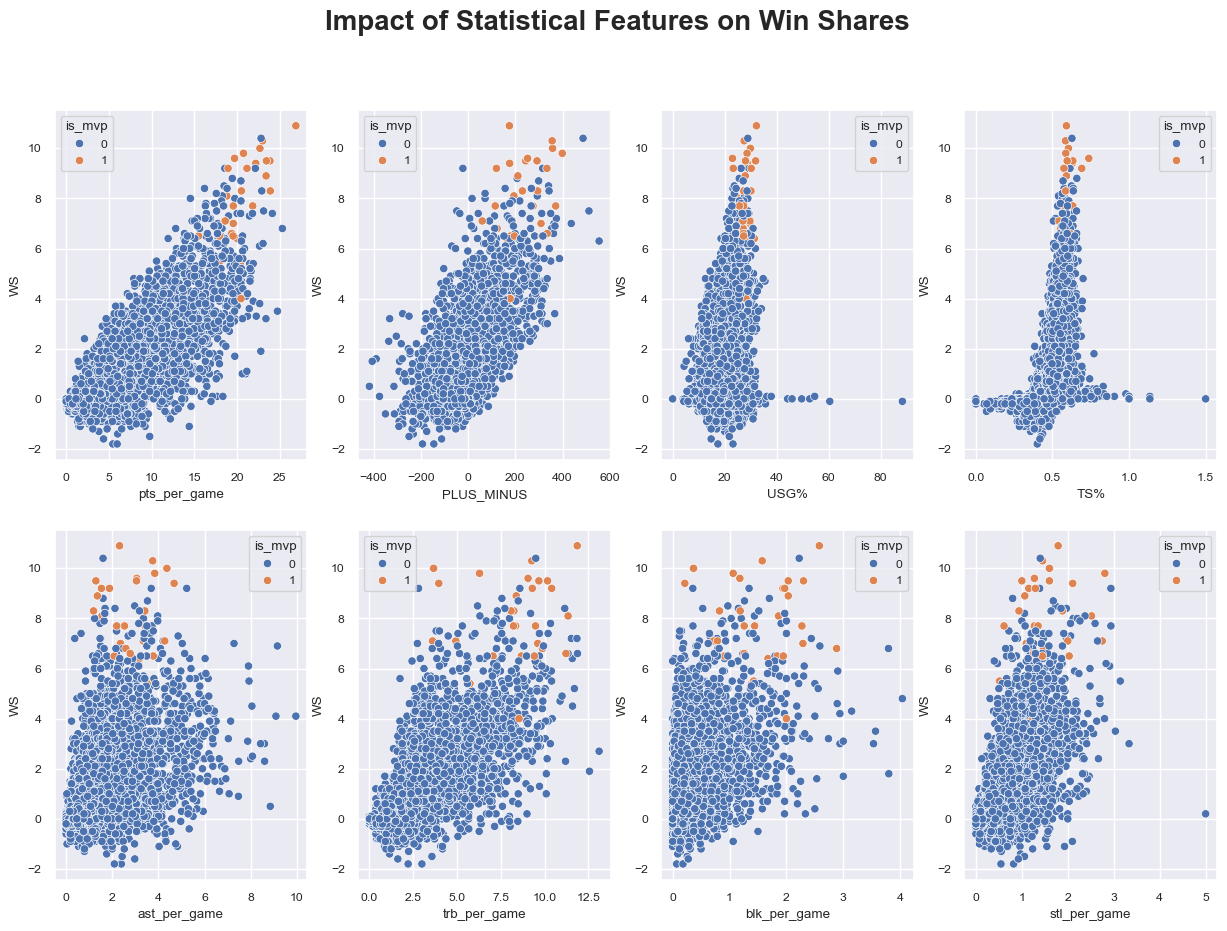

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='pts_per_game',
    y='WS',
    ax=axes[0,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='PLUS_MINUS',
    y='WS',
    ax=axes[0,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='USG%',
    ax=axes[0,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    x='TS%',
    y='WS',
    ax=axes[0,3]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='ast_per_game',
    ax=axes[1,0]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='trb_per_game',
    ax=axes[1,1]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='blk_per_game',
    ax=axes[1,2]
)
sns.scatterplot(
    data=df,
    hue='is_mvp',
    y='WS',
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Impact of Statistical Features on Win Shares', fontsize=20, fontweight='bold')
plt.show()

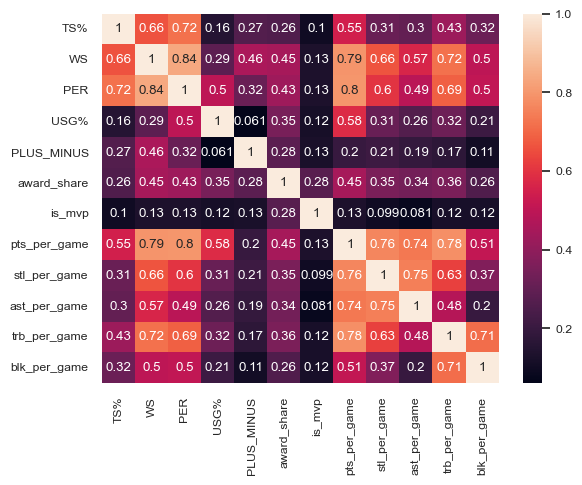

In [10]:
corr_matrix = df[df.columns[2:]].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True)
plt.show()

Award share is correlated with Win Shares and Points per Game the most

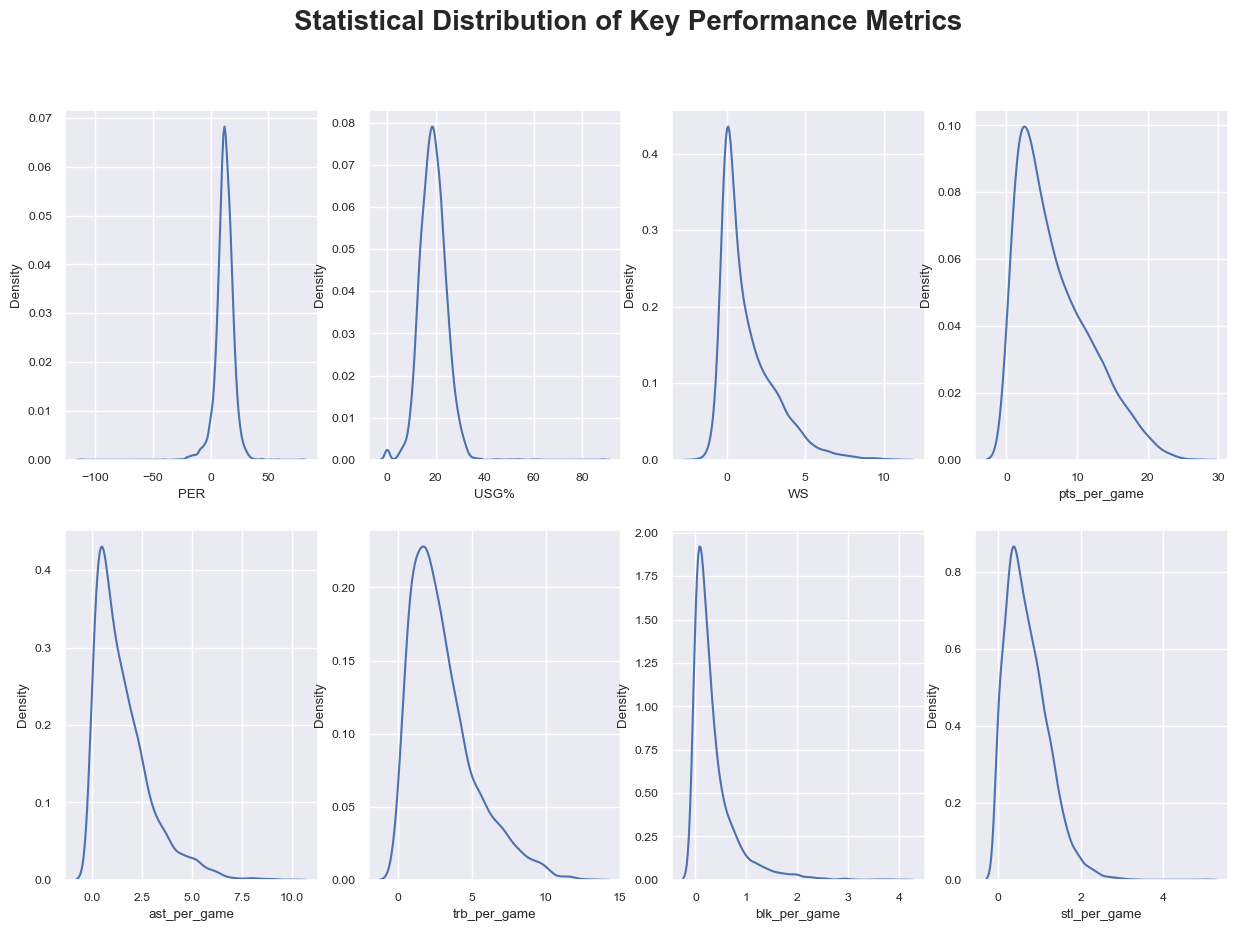

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.kdeplot(
    data=df,
    x='PER',
    ax=axes[0,0]
)
sns.kdeplot(
    data=df,
    x='USG%',
    ax=axes[0,1]
)
sns.kdeplot(
    data=df,
    x='WS',
    ax=axes[0,2]
)
sns.kdeplot(
    data=df,
    x='pts_per_game',
    ax=axes[0,3]
)
sns.kdeplot(
    data=df,
    x='ast_per_game',
    ax=axes[1,0]
)
sns.kdeplot(
    data=df,
    x='trb_per_game',
    ax=axes[1,1]
)
sns.kdeplot(
    data=df,
    x='blk_per_game',
    ax=axes[1,2]
)
sns.kdeplot(
    data=df,
    x='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distribution of Key Performance Metrics', fontsize=20, fontweight='bold')
plt.show()

## Feature Analysis & Statistical Distinctions between MVPS and the rest of the League
To understand what defines an MVP candidate, I analyzed the distributions of 8 core metrics (including PER, Win Shares, Usage Rate, and Plus/Minus) across MVP winners versus the rest of the league.

No single metric tells the whole story. The overlapping distributions between MVPs and runner-ups (outliers in Non-MVPS) indicate that a simple linear model will not suffice; we need tree-based algorithms capable of capturing complex, non-linear feature interactions.

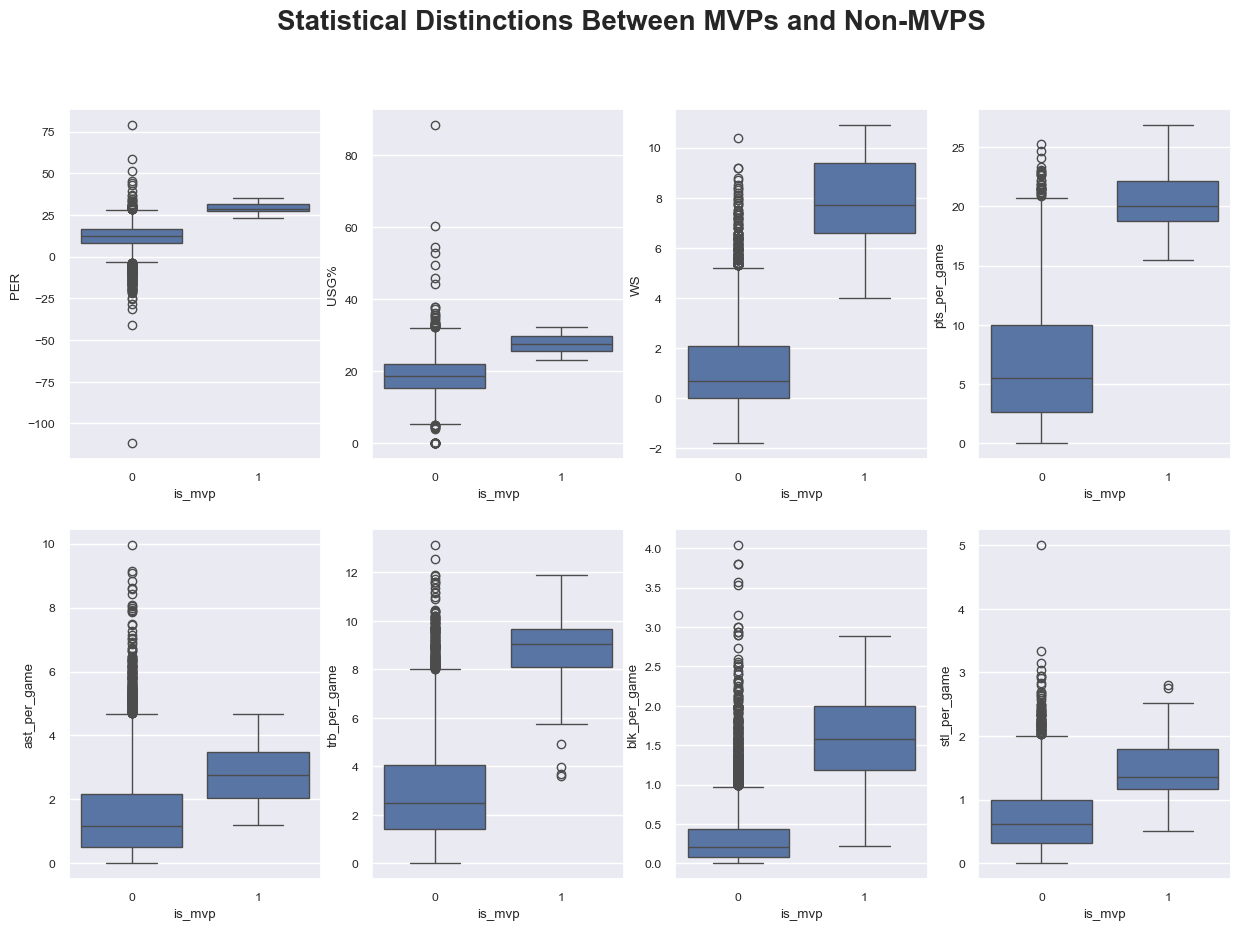

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(15,10))
sns.boxplot(
    data=df,
    x='is_mvp',
    y='PER',
    ax=axes[0,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='USG%',
    ax=axes[0,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='WS',
    ax=axes[0,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='pts_per_game',
    ax=axes[0,3]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='ast_per_game',
    ax=axes[1,0]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='trb_per_game',
    ax=axes[1,1]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='blk_per_game',
    ax=axes[1,2]
)
sns.boxplot(
    data=df,
    x='is_mvp',
    y='stl_per_game',
    ax=axes[1,3]
)
fig.suptitle('Statistical Distinctions Between MVPs and Non-MVPS', fontsize=20, fontweight='bold')
plt.show()

## Target Variable Distribution & Class Imbalance
Before selecting a modeling strategy, we must examine the distribution of our target variable: award_share. As the plots below demonstrate, WNBA MVP voting is a highly exclusive process. Approximately 97% of the league receives zero votes (an award share of 0.0).

This severe class imbalance instantly rules out standard binary classification approaches. A model predicting 0 for every player would achieve 98% accuracy but fail entirely at its objective. Instead, treating this as a continuous regression (predicting the exact award_share) forces the algorithm to learn the nuanced statistical differences among the top 2% of elite players.

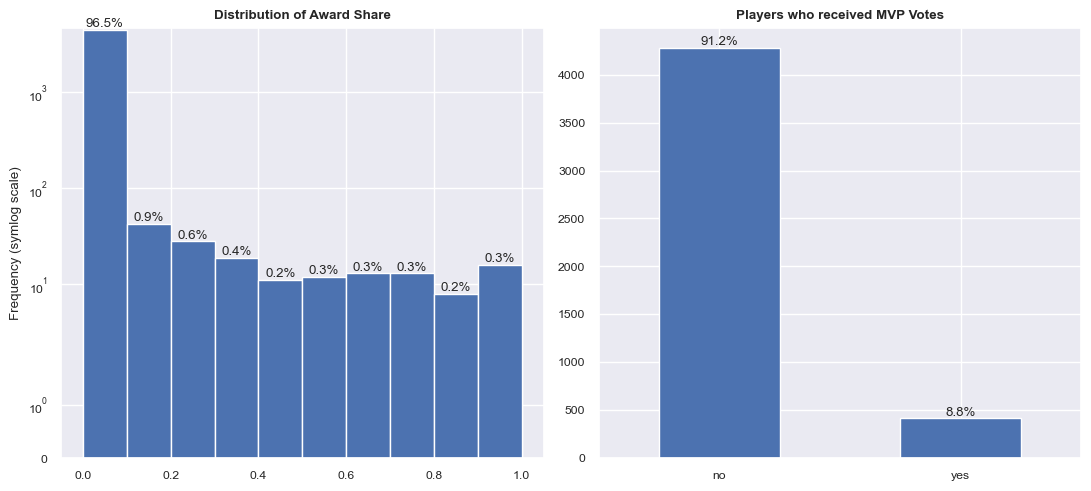

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
total = len(df)

df['award_share'].plot(kind='hist', ax=axes[0])
# Annotate the bars
for p in axes[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom')
axes[0].set_title("Distribution of Award Share", fontweight='bold')
axes[0].set_yscale('symlog')
axes[0].set_ylabel("Frequency (symlog scale)") 

pie_series = pd.Series(np.where(df['award_share'] > 0, 'yes', 'no'))

pie_series.value_counts().plot(kind='bar', ax=axes[1])


for p in axes[1].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                 
    
    axes[1].annotate(percentage, (x, y), ha='center', va='bottom')

axes[1].set_title('Players who received MVP Votes', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=['Season','Player','is_mvp', 'award_share'])

X_standardized = StandardScaler().fit_transform(X)
X_standardized.shape

(4691, 10)

In [15]:
tsne = TSNE(n_components=2, random_state=0)
tsne_X = tsne.fit_transform(X_standardized)
tsne_X

array([[-59.381123  ,  10.950104  ],
       [  0.44379595, -30.431894  ],
       [-49.65098   ,  -4.2110395 ],
       ...,
       [-37.842297  , -29.316021  ],
       [-32.333466  , -19.003181  ],
       [  3.402483  ,  27.515305  ]], shape=(4691, 2), dtype=float32)

In [16]:
tsne_df = pd.DataFrame(data=tsne_X, columns=["Dim_1", "Dim_2"])
tsne_df['is_mvp'] = df['is_mvp'].values
tsne_df['award_share'] = df['award_share'].values

## High-Dimensional Separability (t-SNE Projection)
Can historical MVP voters' decisions be mathematically clustered? Using t-SNE, we compressed our 8-dimensional feature space into a 2D projection. The background layer (grey) represents players with 0.0 award shares, while the color-scaled points represent players who received votes.

The t-SNE projection reveals a distinct "elite cluster" where the true MVP contenders separate from the general league population. However, the presence of high-performing non-MVPs overlap with this cluster confirms that picking the final winner requires highly tuned predictive logic, setting the stage for our gradient boosting models.

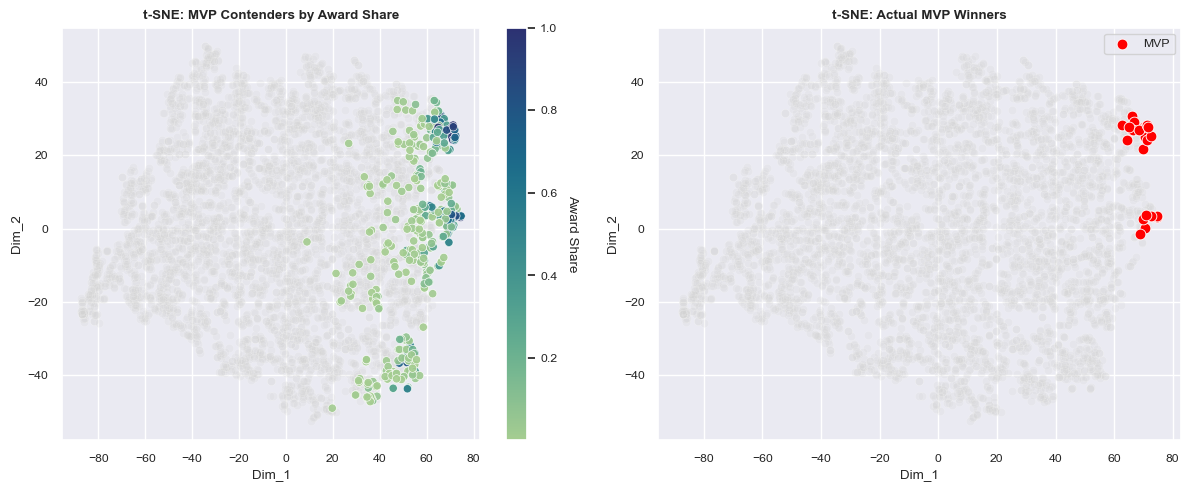

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Layer 1: The Zeros
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] == 0], 
    x='Dim_1', y='Dim_2', 
    color='lightgrey', 
    alpha=0.2, 
    ax=axes[0],
)

# Layer 2: The Contenders 
sns.scatterplot(
    data=tsne_df[tsne_df['award_share'] > 0], 
    x='Dim_1', y='Dim_2', 
    hue='award_share', 
    palette='crest', 
    alpha=0.9, 
    ax=axes[0],
    legend=False 
)

# Continuous Colorbar
min_vote = tsne_df[tsne_df['award_share'] > 0]['award_share'].min()
norm = Normalize(vmin=min_vote, vmax=1)

# a ScalarMappable object using chosen palette and normalizer
sm = plt.cm.ScalarMappable(cmap='crest', norm=norm)
sm.set_array([])

# Attach the colorbar to the first subplot
cbar = fig.colorbar(sm, ax=axes[0])
cbar.set_label('Award Share', rotation=270, labelpad=15) # Add a nice label

axes[0].set_title("t-SNE: MVP Contenders by Award Share", fontweight='bold')


# Plot 2: is_mvp 
sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 0], 
    x='Dim_1', y='Dim_2', color='lightgrey', alpha=0.2, ax=axes[1]
)

sns.scatterplot(
    data=tsne_df[tsne_df['is_mvp'] == 1], 
    x='Dim_1', y='Dim_2', color='red', alpha=1.0, s=60, ax=axes[1], label='MVP'
)
axes[1].set_title("t-SNE: Actual MVP Winners", fontweight='bold')

plt.tight_layout()
plt.show()

## Problem Framing

Rather than treating MVP selection as binary classification, this model predicts `award_share` —
each player-season's fraction of MVP voting points. 96.5% of player-seasons receive exactly zero
votes, which makes binary classification close to meaningless here; regression on vote share lets
the model learn *how close* a player was to MVP, not just yes/no, and naturally produces a ranking
within each season.
## Validation Strategy: Walk-Forward, Not Random Split

Every model is evaluated with an expanding-window walk-forward split: train on all seasons before
year Y, test only on year Y, then advance one season at a time from 1999 through 2025. A random
train/test split would let future seasons leak into training — this protocol mirrors how an
in-season prediction system actually operates and avoids that leakage entirely.
## Feature Engineering: Season-Relative Normalization

WNBA pace and scoring have shifted substantially since 1997. Raw per-game stats don't capture *how
dominant* a player was relative to her peers in a given year — which is what MVP voting actually
reflects. Each feature was converted to a within-season z-score. A controlled ablation (identical
model, identical hyperparameters, only the feature representation changed) confirmed this helps:
R² improved from 0.646 (raw features) to 0.686 (season-normalized), on the same data.

In [18]:
# normalize features within season
# What actually determines MVP voting is how dominant a player was relative to her peers that year — not her raw numbers.
season_cols = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game', 'ast_per_game',
               'trb_per_game', 'blk_per_game', 'stl_per_game'] # plus minus is a season total, not a per-game rate

for col in season_cols:
    df[f'{col}_z'] = df.groupby('Season')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

df_sorted = df.sort_values(by=['Season', 'Player']).reset_index(drop=True)

features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z','pts_per_game_z', 'ast_per_game_z',
             'trb_per_game_z', 'blk_per_game_z','stl_per_game_z']
target = 'award_share'

def walk_forward_validation(estimator,features=features,target=target ,df=df,start_test_year=1999, end_test_year=2025):
    yearly_r2 = {}
    yearly_rmse = {}
    all_model_predictions = []

    for test_year in range(start_test_year, end_test_year+1):
        
        train_data = df[df['Season'] < test_year]
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]
        
        estimator.fit(X_train, y_train)
        
        y_pred = estimator.predict(X_test)

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Prediction': y_pred
        })
    
        eval_df['Prediction'] = eval_df['Prediction'].clip(lower=0)
        all_model_predictions.append(eval_df)

        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)**(1/2)

        yearly_r2[test_year] = r2
        yearly_rmse[test_year] = rmse
    
    final_predictions_df = pd.concat(all_model_predictions, ignore_index=True)
    overall_r2 = sum(yearly_r2.values())/len(yearly_r2)
    overall_rmse = sum(yearly_rmse.values())/len(yearly_rmse)
    
    return {'overall_r2':overall_r2, 'overall_rmse':overall_rmse, 'final_predictions':final_predictions_df}

In [19]:
raw_features = ['TS%', 'WS', 'PER', 'USG%', 'pts_per_game',
                'ast_per_game', 'trb_per_game', 'blk_per_game', 'stl_per_game']

z_features = ['TS%_z', 'WS_z', 'PER_z', 'USG%_z', 'pts_per_game_z',
              'ast_per_game_z', 'trb_per_game_z', 'blk_per_game_z', 'stl_per_game_z']

default_params = dict(loss_function='RMSE', random_state=0, verbose=0)  # identical params both runs

raw_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), raw_features, target, df_sorted
)
z_results = walk_forward_validation(
    catboost.CatBoostRegressor(**default_params), z_features, target, df_sorted
)

print("Raw R²:", raw_results['overall_r2'])
print("Season-normalized R²:", z_results['overall_r2'])

Raw R²: 0.6461307708148892
Season-normalized R²: 0.686181806998142


In [20]:
# helper functions
def get_comparison_table(results_df):
    sorted_preds = results_df.sort_values(
    by=['Season', 'Prediction'], 
    ascending=[True, False]
    )
    predicted_mvps = sorted_preds.groupby('Season').head(1).reset_index(drop=True)

    actual_mvps = results_df.sort_values(
        by=['Season','Actual_Share'], ascending=[True, False]
    ).groupby('Season').head(1)[['Season','Player']].rename(columns={'Player':'Actual_MVP'})

    return predicted_mvps.rename(
        columns={'Player':'Predicted_MVP'}
        ).merge(actual_mvps, on='Season')

# returns percentage of successful hits by the model
# i.e. for k=3 , if the model predicted the mvp in the top 3 in predicted award shares that's a hit
def topk_hit_rate(predictions_df, k=3, score_col='Prediction'):
    hits = []
    for season, group in predictions_df.groupby('Season'):
        top_k = group.sort_values(score_col, ascending=False).head(k)['Player']
        actual_mvp = group.sort_values('Actual_Share', ascending=False).iloc[0]['Player']
        hits.append(actual_mvp in top_k.values)
    return sum(hits) / len(hits)

## How Far Can a Single Feature Take You?

Win Shares (WS) is moderately correlated with MVP voting (Spearman ρ=0.447). To
quantify exactly how far this single feature goes, a model trained on WS alone was compared against
the full 9-feature models across different windows: r_2 score, rmse, hit@1 and hit@3.

In [21]:
def catb_objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 1, 2),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 100, 300),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'RMSE',
        'random_state': 0,
        'verbose': 0,
    }
    results = walk_forward_validation(
        estimator=catboost.CatBoostRegressor(**params),
        features=['WS_z'], start_test_year=2013,
    )
    return results['overall_r2']

single_feature_study = optuna.create_study(direction='maximize')
single_feature_study.optimize(catb_objective, n_trials=40)
print(single_feature_study.best_params, single_feature_study.best_value)

[I 2026-06-22 19:54:38,350] A new study created in memory with name: no-name-97395b54-2bd0-4f02-bb35-0853a426e443
[I 2026-06-22 19:54:40,567] Trial 0 finished with value: 0.6457233663754043 and parameters: {'depth': 1, 'learning_rate': 0.012184679198417642, 'iterations': 277, 'l2_leaf_reg': 7.9254031055817205}. Best is trial 0 with value: 0.6457233663754043.
[I 2026-06-22 19:54:42,624] Trial 1 finished with value: 0.6494308982193295 and parameters: {'depth': 2, 'learning_rate': 0.01387551486301192, 'iterations': 181, 'l2_leaf_reg': 4.073095878446278}. Best is trial 1 with value: 0.6494308982193295.
[I 2026-06-22 19:54:44,820] Trial 2 finished with value: 0.652054674354609 and parameters: {'depth': 1, 'learning_rate': 0.01410759137758118, 'iterations': 270, 'l2_leaf_reg': 8.254669816987448}. Best is trial 2 with value: 0.652054674354609.
[I 2026-06-22 19:54:47,743] Trial 3 finished with value: 0.6766394604517865 and parameters: {'depth': 2, 'learning_rate': 0.05946273100607136, 'iterati

{'depth': 2, 'learning_rate': 0.05243321142725819, 'iterations': 296, 'l2_leaf_reg': 6.069745115063078} 0.677033954116875


In [22]:
single_feature_results = walk_forward_validation(
    estimator=catboost.CatBoostRegressor(**single_feature_study.best_params, verbose=0, random_state=0),
    features=['WS_z'], start_test_year=2013
)

print("R_2:", single_feature_results['overall_r2'])
print("Rmse:", single_feature_results['overall_rmse'])

single_feature_comparison = get_comparison_table(single_feature_results['final_predictions'])
single_feature_comparison

R_2: 0.677033954116875
Rmse: 0.055317423942998815


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Maya Moore,0.623,0.550369,Candace Parker
1,2014,Maya Moore,0.976,0.709613,Maya Moore
2,2015,Elena Delle Donne,0.987,0.726858,Elena Delle Donne
3,2016,Nneka Ogwumike,0.928,0.749051,Nneka Ogwumike
4,2017,Sylvia Fowles,0.962,0.761871,Sylvia Fowles
5,2018,Breanna Stewart,0.954,0.535403,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.775852,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.343062,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.607047,Jonquel Jones
9,2022,Breanna Stewart,0.796,0.630854,A'ja Wilson


In [23]:
def xgb_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'eta': trial.suggest_float('eta', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'random_state': 0,
    }
    results = walk_forward_validation(
        estimator=xgboost.XGBRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2013, end_test_year=2025
    )
    return results['overall_r2']

study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=40)
print(study.best_params, study.best_value)

[I 2026-06-22 19:56:19,977] A new study created in memory with name: no-name-f7b33be1-4293-446b-ae4e-da2372f2d6d3
[I 2026-06-22 19:56:22,620] Trial 0 finished with value: 0.7684427101372506 and parameters: {'max_depth': 4, 'eta': 0.042501699160315556, 'n_estimators': 384, 'subsample': 0.7892995076737881}. Best is trial 0 with value: 0.7684427101372506.
[I 2026-06-22 19:56:24,362] Trial 1 finished with value: 0.7575225539853209 and parameters: {'max_depth': 4, 'eta': 0.10254347736316852, 'n_estimators': 266, 'subsample': 0.7143158344670597}. Best is trial 0 with value: 0.7684427101372506.
[I 2026-06-22 19:56:27,895] Trial 2 finished with value: 0.7486549432909472 and parameters: {'max_depth': 8, 'eta': 0.046104569254041945, 'n_estimators': 200, 'subsample': 0.9593831752587214}. Best is trial 0 with value: 0.7684427101372506.
[I 2026-06-22 19:56:30,152] Trial 3 finished with value: 0.7780410267566946 and parameters: {'max_depth': 5, 'eta': 0.017598462845812207, 'n_estimators': 272, 'subs

{'max_depth': 4, 'eta': 0.010754310947034213, 'n_estimators': 719, 'subsample': 0.5037648090994576} 0.7824577707665928


In [24]:
def catb_objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 200, 800),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'loss_function': 'RMSE',
        'random_state': 0,
        'verbose': 0,
    }
    results = walk_forward_validation(
        estimator=catboost.CatBoostRegressor(**params),
        features=features, target=target, df=df_sorted,
        start_test_year=2013, end_test_year=2025 
    )
    return results['overall_r2']

study2 = optuna.create_study(direction='maximize')
study2.optimize(catb_objective, n_trials=40)
print(study2.best_params, study2.best_value)

[I 2026-06-22 19:59:36,539] A new study created in memory with name: no-name-44deb7e0-f163-4100-a2a4-96578494b7b5
[I 2026-06-22 19:59:47,150] Trial 0 finished with value: 0.7758511241566487 and parameters: {'depth': 4, 'learning_rate': 0.011361939803699421, 'iterations': 712, 'l2_leaf_reg': 3.5630287805213574}. Best is trial 0 with value: 0.7758511241566487.
[I 2026-06-22 19:59:54,528] Trial 1 finished with value: 0.7640238274886683 and parameters: {'depth': 5, 'learning_rate': 0.070147293621227, 'iterations': 382, 'l2_leaf_reg': 9.016816911898406}. Best is trial 0 with value: 0.7758511241566487.
[I 2026-06-22 20:00:04,597] Trial 2 finished with value: 0.7447270951279884 and parameters: {'depth': 4, 'learning_rate': 0.09295572455909475, 'iterations': 695, 'l2_leaf_reg': 9.070221316217811}. Best is trial 0 with value: 0.7758511241566487.
[I 2026-06-22 20:00:09,159] Trial 3 finished with value: 0.764719459630419 and parameters: {'depth': 3, 'learning_rate': 0.06696043863879013, 'iteratio

{'depth': 3, 'learning_rate': 0.0118000757062022, 'iterations': 799, 'l2_leaf_reg': 2.691003552003842} 0.7771970190168648


In [25]:
def lightgbm_objective(trial):
    params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': trial.suggest_int('num_leaves', 63, 127),
    'learning_rate': trial.suggest_float('learning_rate', 0.01,0.05),
    'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.7),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.7),
    'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
    'random_state':0,
    'verbose':-1
    }
    results = walk_forward_validation(
        estimator=lightgbm.LGBMRegressor(**params),
        features=features,target=target, df=df_sorted,
        start_test_year=2013,end_test_year=2025 
    )
    return results['overall_r2']

study3 = optuna.create_study(direction='maximize')
study3.optimize(lightgbm_objective, n_trials=40)
print(study3.best_params, study3.best_value)

[I 2026-06-22 20:06:29,645] A new study created in memory with name: no-name-2429fbd3-0160-4d8c-8a7e-63e2a43fcceb
[I 2026-06-22 20:06:30,957] Trial 0 finished with value: 0.7094160295883133 and parameters: {'num_leaves': 106, 'learning_rate': 0.026579754321655734, 'feature_fraction': 0.6487853371816885, 'colsample_bytree': 0.6897402557531929, 'min_child_samples': 44}. Best is trial 0 with value: 0.7094160295883133.
[I 2026-06-22 20:06:32,230] Trial 1 finished with value: 0.7214856732208144 and parameters: {'num_leaves': 65, 'learning_rate': 0.021447694435576606, 'feature_fraction': 0.6161232373245096, 'colsample_bytree': 0.6237644343746188, 'min_child_samples': 33}. Best is trial 1 with value: 0.7214856732208144.
[I 2026-06-22 20:06:33,529] Trial 2 finished with value: 0.7702437489054379 and parameters: {'num_leaves': 71, 'learning_rate': 0.04428623337064211, 'feature_fraction': 0.6322310067692424, 'colsample_bytree': 0.649573388307328, 'min_child_samples': 10}. Best is trial 2 with va

{'num_leaves': 71, 'learning_rate': 0.049563434495416704, 'feature_fraction': 0.6962401400313154, 'colsample_bytree': 0.620274298444261, 'min_child_samples': 16} 0.7814032933007596


In [26]:
def walk_forward_validation_ranker(estimator, features=features, target=target, df=df_sorted, start_test_year=1999, end_test_year=2025):
    all_preds = []
    hits = []

    for test_year in range(start_test_year, end_test_year + 1):
        train_data = df[df['Season'] < test_year].sort_values('Season')  # must be contiguous by group
        test_data = df[df['Season'] == test_year]

        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]

        group_sizes = train_data.groupby('Season').size().values

        estimator.fit(X_train, y_train, group=group_sizes)
        y_pred = estimator.predict(X_test)   # raw ranking score — NOT an award_share estimate

        eval_df = pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Prediction': y_pred
        })
        all_preds.append(eval_df)

        predicted_top = eval_df.loc[eval_df['Prediction'].idxmax(), 'Player']
        actual_top = eval_df.loc[eval_df['Actual_Share'].idxmax(), 'Player']
        hits.append(predicted_top == actual_top)

    final_predictions_df = pd.concat(all_preds, ignore_index=True)
    return {'hit_rate': sum(hits) / len(hits), 'final_predictions': final_predictions_df}

In [27]:
ranker = xgboost.XGBRanker(objective='rank:pairwise', random_state=0)
ranker_results = walk_forward_validation_ranker(
    estimator=ranker, start_test_year=2015
)

print(f"Top-1 hit rate: {ranker_results['hit_rate']:.2%}")

predicted_mvps_ranker = get_comparison_table(ranker_results['final_predictions'])
predicted_mvps_ranker

Top-1 hit rate: 63.64%


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2015,Maya Moore,0.631,6.917254,Elena Delle Donne
1,2016,Maya Moore,0.505,5.849581,Nneka Ogwumike
2,2017,Sylvia Fowles,0.962,5.446976,Sylvia Fowles
3,2018,Liz Cambage,0.592,5.677861,Breanna Stewart
4,2019,Elena Delle Donne,0.977,5.336360,Elena Delle Donne
5,2020,Breanna Stewart,0.655,3.992705,A'ja Wilson
6,2021,Jonquel Jones,0.994,5.672103,Jonquel Jones
7,2022,A'ja Wilson,0.854,6.536408,A'ja Wilson
8,2023,Breanna Stewart,0.743,7.229391,Breanna Stewart
9,2024,A'ja Wilson,1.000,6.147622,A'ja Wilson


In [28]:
catb = catboost.CatBoostRegressor(**study2.best_params, loss_function='RMSE', random_state=0, verbose=0)
xgb = xgboost.XGBRegressor(**study.best_params, random_state=0)
lgbm = lightgbm.LGBMRegressor(**study3.best_params, random_state=0, verbose=-1)

In [29]:
catb_results = walk_forward_validation(
                estimator=catb,
                features=features,
                target=target,
                start_test_year=2013)

print(f'r2: {catb_results['overall_r2']}')
print(f'rmse: {catb_results['overall_rmse']}')

comparison_catb = get_comparison_table(catb_results['final_predictions'])
comparison_catb

r2: 0.7746227004856455
rmse: 0.0455736602690583


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Candace Parker,0.669,0.343839,Candace Parker
1,2014,Maya Moore,0.976,0.773579,Maya Moore
2,2015,Elena Delle Donne,0.987,0.727100,Elena Delle Donne
3,2016,Maya Moore,0.505,0.499536,Nneka Ogwumike
4,2017,Nneka Ogwumike,0.222,0.497488,Sylvia Fowles
5,2018,Liz Cambage,0.592,0.721014,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.613122,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.425836,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.596742,Jonquel Jones
9,2022,Breanna Stewart,0.796,0.665196,A'ja Wilson


In [30]:
xgb_results = walk_forward_validation(
    estimator=xgb,
    features=features,
    target=target,
    start_test_year=2013
    )

print(f'r2: {xgb_results['overall_r2']}')
print(f'rmse: {xgb_results['overall_rmse']}')

comparison_xgb = get_comparison_table(xgb_results['final_predictions'])
comparison_xgb

r2: 0.7872136512763327
rmse: 0.044366595764886115


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Candace Parker,0.669,0.365974,Candace Parker
1,2014,Maya Moore,0.976,0.715576,Maya Moore
2,2015,Elena Delle Donne,0.987,0.755061,Elena Delle Donne
3,2016,Maya Moore,0.505,0.613058,Nneka Ogwumike
4,2017,Sylvia Fowles,0.962,0.548633,Sylvia Fowles
5,2018,Liz Cambage,0.592,0.665025,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.566363,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.504167,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.663122,Jonquel Jones
9,2022,Breanna Stewart,0.796,0.650811,A'ja Wilson


In [31]:
lgbm_results = walk_forward_validation(
                estimator=lgbm,
                features=features,
                target=target,
                start_test_year=2013)

print(f'r2: {lgbm_results['overall_r2']}')
print(f'rmse: {lgbm_results['overall_rmse']}')

comparison_lgbm = get_comparison_table(lgbm_results['final_predictions'])
comparison_lgbm

r2: 0.7814032933007596
rmse: 0.04484022381871379


,Season,Predicted_MVP,Actual_Share,Prediction,Actual_MVP
0,2013,Candace Parker,0.669,0.425547,Candace Parker
1,2014,Maya Moore,0.976,0.701646,Maya Moore
2,2015,Elena Delle Donne,0.987,0.742248,Elena Delle Donne
3,2016,Maya Moore,0.505,0.551832,Nneka Ogwumike
4,2017,Sylvia Fowles,0.962,0.525376,Sylvia Fowles
5,2018,Liz Cambage,0.592,0.639875,Breanna Stewart
6,2019,Elena Delle Donne,0.977,0.667115,Elena Delle Donne
7,2020,Breanna Stewart,0.655,0.478086,A'ja Wilson
8,2021,Jonquel Jones,0.994,0.545129,Jonquel Jones
9,2022,A'ja Wilson,0.854,0.676341,A'ja Wilson


In [32]:
k=1
print(f"at k={k}")
print(f"CatBoost on Win Shares only hit@{k}:", topk_hit_rate(single_feature_results['final_predictions'], k=k))
print(f"CatBoost hit@{k}:", topk_hit_rate(catb_results['final_predictions'], k=k))
print(f"LightGBM hit@{k}:", topk_hit_rate(lgbm_results['final_predictions'], k=k))
print(f"XGBoost hit@{k}:", topk_hit_rate(xgb_results['final_predictions'], k=k))
print(f"Ranker hit@{k}:  ", topk_hit_rate(ranker_results['final_predictions'], k=k, score_col='Prediction'))
k=2
print(f"at k={k}")
print(f"CatBoost on Win Shares only hit@{k}:", topk_hit_rate(single_feature_results['final_predictions'], k=k))
print(f"CatBoost hit@{k}:", topk_hit_rate(catb_results['final_predictions'], k=k))
print(f"LightGBM hit@{k}:", topk_hit_rate(lgbm_results['final_predictions'], k=k))
print(f"XGBoost hit@{k}:", topk_hit_rate(xgb_results['final_predictions'], k=k))
print(f"Ranker hit@{k}:  ", topk_hit_rate(ranker_results['final_predictions'], k=k, score_col='Prediction'))

at k=1
CatBoost on Win Shares only hit@1: 0.7692307692307693
CatBoost hit@1: 0.5384615384615384
LightGBM hit@1: 0.6923076923076923
XGBoost hit@1: 0.6153846153846154
Ranker hit@1:   0.6363636363636364
at k=2
CatBoost on Win Shares only hit@2: 0.8461538461538461
CatBoost hit@2: 1.0
LightGBM hit@2: 1.0
XGBoost hit@2: 1.0
Ranker hit@2:   0.9090909090909091


Text(0.5, 1.0, 'XGBoost Regressor Model')

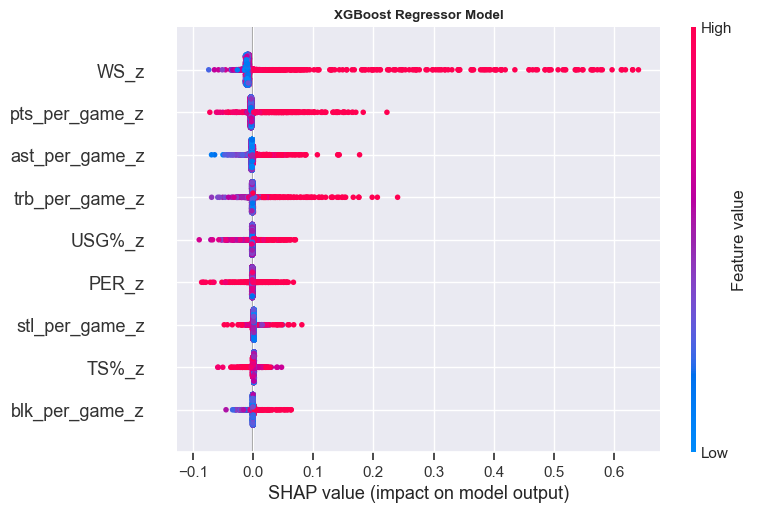

In [33]:
xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer(df[features])
shap.summary_plot(xgb_shap_values, df[features], show=False)
plt.title("XGBoost Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'CATBoost Regressor Model')

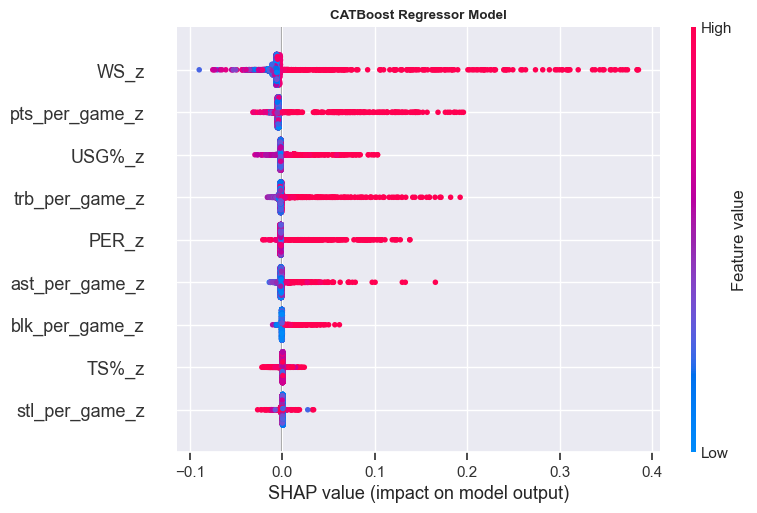

In [34]:
explainer = shap.TreeExplainer(catb)
shap_values = explainer(df[features])

shap.summary_plot(shap_values, df[features], show=False)
plt.title("CATBoost Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'LightGBM Regressor Model')

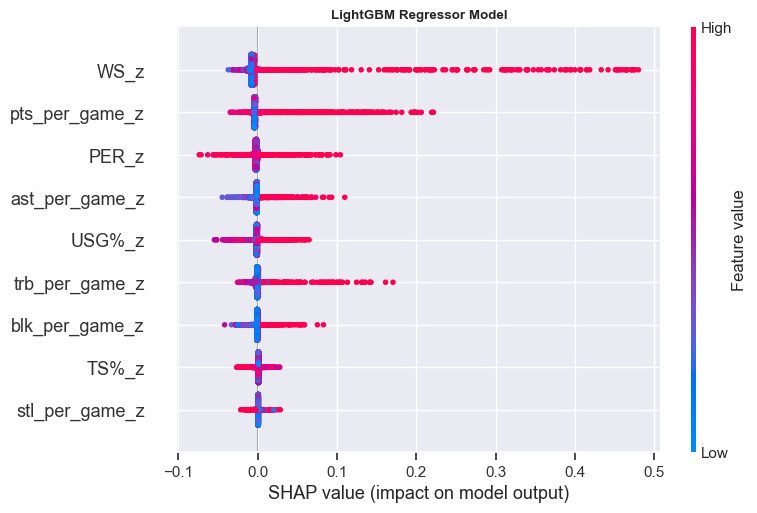

In [35]:
lightgbm_explainer = shap.TreeExplainer(lgbm)
lightgbm_shap_values = lightgbm_explainer(df[features])
shap.summary_plot(lightgbm_shap_values, df[features], show=False)
plt.title("LightGBM Regressor Model", fontweight='bold')

Text(0.5, 1.0, 'XGBoost Ranker Model')

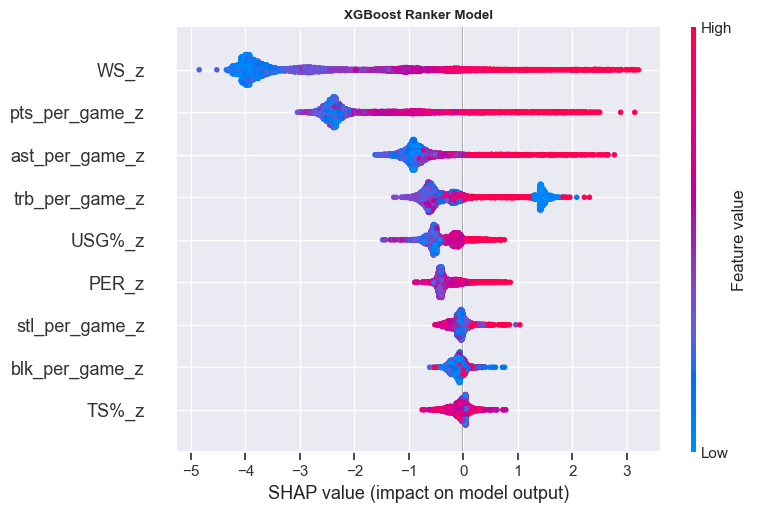

In [36]:
xgbranker_explainer = shap.TreeExplainer(ranker)
xgbranker_shap_values = xgbranker_explainer(df[features])
shap.summary_plot(xgbranker_shap_values, df[features], show=False)
plt.title("XGBoost Ranker Model", fontweight='bold')

## Model Comparison & Final Choice

CatBoost, XGBoost, and LightGBM were each tuned with Optuna (optimizing directly against the
walk-forward loop, not a generic CV proxy) and compared against an XGBoost-based learning-to-rank
model. SHAP analysis showed all four converge on the same dominant feature (`WS_z`), but they
showed measurably different strengths in a head-to-head hit-rate comparison: CatBoost/XGBoost were
most reliable at hit@2/hit@3, LightGBM was sharper at hit@1 in lopsided recent seasons, and the
ranker underperformed the regression approaches across every controlled test. Given these were
genuinely complementary rather than redundant, the final model averages CatBoost, XGBoost, and
LightGBM's predictions rather than selecting a single winner — achieving R²= 0.7898 and a hit@1
of 0.615 across the full 1999–2025 evaluation.

In [ ]:
def walk_forward_ensemble(estimators, features=features, target=target, df=df_sorted, start_test_year=1999, end_test_year=2025):
    all_preds = []
    for test_year in range(start_test_year, end_test_year + 1):
        train_data = df[df['Season'] < test_year]
        test_data = df[df['Season'] == test_year]
        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test = test_data[features], test_data[target]

        preds = {}
        for name, est in estimators.items():
            est.fit(X_train, y_train)
            preds[name] = np.clip(est.predict(X_test), 0, None)

        ensemble_pred = np.mean(list(preds.values()), axis=0)

        all_preds.append(pd.DataFrame({
            'Season': test_data['Season'].values,
            'Player': test_data['Player'].values,
            'Actual_Share': y_test.values,
            'Prediction': ensemble_pred
        }))

    final_predictions_df = pd.concat(all_preds, ignore_index=True)
    return {
        'overall_r2': r2_score(final_predictions_df['Actual_Share'], final_predictions_df['Prediction']),
        'overall_rmse': mean_squared_error(final_predictions_df['Actual_Share'], final_predictions_df['Prediction'])**0.5,
        'final_predictions': final_predictions_df
    }

ensemble_results = walk_forward_ensemble(
    estimators={
        'catb': catboost.CatBoostRegressor(**study2.best_params, loss_function='RMSE', random_state=0, verbose=0),
        'xgb':  xgboost.XGBRegressor(**study.best_params, random_state=0),
        'lgbm': lightgbm.LGBMRegressor(**study3.best_params, random_state=0, verbose=-1),
    },
    start_test_year=2013
)

print("Ensemble R²:", ensemble_results['overall_r2'])
print("Ensemble R²:", ensemble_results['overall_rmse'])
print("Ensemble hit@1:", topk_hit_rate(ensemble_results['final_predictions'], k=1))
print("Ensemble hit@2:", topk_hit_rate(ensemble_results['final_predictions'], k=2))
print("Ensemble hit@3:", topk_hit_rate(ensemble_results['final_predictions'], k=3))

Ensemble R²: 0.7900357720058048
Ensemble R²: 0.04524454426555793
Ensemble hit@1: 0.6153846153846154
Ensemble hit@2: 1.0
Ensemble hit@3: 1.0


## Next Steps

This notebook covers training and evaluation. The next phase of this project moves to live
deployment: weekly ingestion of in-progress 2026 season stats, partial-season-aware feature
normalization, and a serving layer for continuously updated MVP race predictions.